In [1]:
# Instala as bibliotecas necessárias no ambiente associado ao kernel.
%pip install swifter sentence-transformers umap-learn bertopic plotly scipy wordcloud matplotlib

# Importações para limpeza de texto e análise estatística.
import re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from collections import Counter
from scipy.stats import zscore
import swifter

# Carrega o modelo de português do spaCy; baixa-o se ainda não estiver disponível.
import spacy
try:
    nlp_global = spacy.load('pt_core_news_sm')
except OSError:
    print("Baixando o modelo 'pt_core_news_sm' do spaCy. Isso pode levar alguns minutos...")
    !python -m spacy download pt_core_news_sm
    nlp_global = spacy.load('pt_core_news_sm')

# Importações para embeddings, redução de dimensionalidade e tópicos.
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import plotly.express as px
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from umap import UMAP

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.7 MB/s eta 0:00:00
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16589 sha256=c2158b169eacb795d2b19be52961554e690596927fb4853e94b42d7b0e01223e
  Stored in directory: /root/.cache/pip/wheels/e8/a1/09/564d4c4662764b4113f97a9b2b9a5cf15a5dbf86428c8d3658
Successfully built swifter
Baixando o modelo 'pt_core_news_sm' do spaCy. Isso pode levar alguns minutos...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 59.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Recursos de Tokenização do NLTK

In [2]:
import nltk

# Baixa recursos de tokenização e a lista de stopwords em português.
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Funções Auxiliares para Limpeza e Contagem

In [3]:
import re
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Guarda as palavras comuns do português para reutilizá-las na limpeza.
cachedStopWords = stopwords.words("portuguese")
# Adiciona os dias da semana e 'feira' à lista de stopwords.
days_of_week_and_feira = ['segunda', 'terça', 'quarta', 'quinta', 'sexta', 'sábado', 'domingo', 'feira']
cachedStopWords.extend(days_of_week_and_feira)
sw = set(cachedStopWords)


def remover_simbolos(texto):
    "Substitui pontuação por espaços sem remover acentos do português."
    return re.sub(r"[^\w\s]", " ", str(texto), flags=re.UNICODE)


def normalizar_espacos(texto):
    "Remove espaços repetidos e espaços no início ou no fim."
    return re.sub(r"\s+", " ", texto).strip()


def remover_stopwords(texto):
    "Remove palavras frequentes que pouco ajudam na análise temática."
    tokens = word_tokenize(texto, language="portuguese")
    palavras_relevantes = [
        palavra for palavra in tokens
        if palavra.lower() not in sw
    ]
    return " ".join(palavras_relevantes)


def contar_palavras(texto):
    "Conta os termos separados por espaço; valores ausentes contam como zero."
    if isinstance(texto, str):
        return len(texto.split())
    return 0


def obter_top_n_palavras(textos, n=None):
    "Retorna as palavras mais frequentes, ignorando stopwords e palavras de uma única letra ou dígitos."
    frequencias = Counter()
    for texto in textos:
        if isinstance(texto, str):
            frequencias.update(
                palavra for palavra in texto.split()
                if palavra.lower() not in sw and len(palavra) > 1 and not palavra.isdigit() # Filtra palavras de uma letra e dígitos
            )
    return frequencias.most_common(n)


In [4]:
# Bibliotecas usadas na leitura dos dados e nas visualizações.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy

# O caminho abaixo é específico do Google Colab e deve apontar para o CSV usado.
from google.colab import drive
drive.mount('/content/drive')
caminho_arquivo = '/content/drive/MyDrive/Colab Notebooks/Historico_de_materias.csv'

# Carrega a base e confere sua estrutura antes do pré-processamento.
df = pd.read_csv(caminho_arquivo)
print(f"Registros: {len(df):,} | Colunas: {len(df.columns)}")
display(df.head())

# Mantém uma cópia textual segura e cria uma versão normalizada para análise.
df['conteudo_noticia'] = df['conteudo_noticia'].fillna('').astype(str)
df['texto_limpo'] = df['conteudo_noticia'].str.lower().map(remover_simbolos)
df['texto_limpo'] = df['texto_limpo'].map(normalizar_espacos)
df['texto_limpo'] = df['texto_limpo'].map(remover_stopwords)

# Compare uma amostra original e limpa para avaliar o efeito das transformações.
display(df[['conteudo_noticia', 'texto_limpo']].head())

Mounted at /content/drive
Registros: 10,109 | Colunas: 6


,data,url_noticia,url_noticia_curto,titulo,conteudo_noticia,assunto
0,2014-01-25,https://web.archive.org/web/20140125123631/htt...,http://g1.globo.com/economia/noticia/2014/01/m...,"Mesmo com alta do dólar, gastos de brasileiros...","\n\tA alta de 15% no dólar em 2013, a maior do...",economia
1,2014-01-25,https://web.archive.org/web/20140125123631/htt...,http://g1.globo.com/economia/noticia/2014/01/p...,"Para Dilma, é 'apressada' a tese de que emerge...",\n\tA presidente Dilma Rousseff afirmou nesta ...,economia
2,2014-01-25,https://web.archive.org/web/20140125123631/htt...,http://g1.globo.com/economia/noticia/2014/01/t...,"Temos sido capazes de reduzir a inflação', diz...","\n\tO presidente do Banco Central, Alexandre T...",economia
3,2014-01-25,https://web.archive.org/web/20140125123631/htt...,http://g1.globo.com/economia/noticia/2014/01/g...,Governo argentino autoriza compra de dólares a...,\n\tO governo argentino anunciou nesta sexta-f...,economia
4,2014-01-25,https://web.archive.org/web/20140125123631/htt...,http://g1.globo.com/economia/noticia/2014/01/p...,Petrobras desiste de parte da área de Bem-te-v...,\n\tA Petrobras afirmou que propôs à Agência N...,economia


,conteudo_noticia,texto_limpo
0,"\n\tA alta de 15% no dólar em 2013, a maior do...",alta 15 dólar 2013 maior últimos cinco anos re...
1,\n\tA presidente Dilma Rousseff afirmou nesta ...,presidente dilma rousseff afirmou nesta 24 dur...
2,"\n\tO presidente do Banco Central, Alexandre T...",presidente banco central alexandre tombini dis...
3,\n\tO governo argentino anunciou nesta sexta-f...,governo argentino anunciou nesta 24 permitirá ...
4,\n\tA Petrobras afirmou que propôs à Agência N...,petrobras afirmou propôs agência nacional petr...


## Medidas Textuais e N-gramas

In [5]:
import pandas as pd
import numpy as np


def obter_ngrams(texto, n=2):
    """Gera sequências de n palavras a partir de um texto tokenizado, filtrando números e palavras de uma única letra."""
    tokens = word_tokenize(str(texto), language='portuguese')
    sequencias = nltk.ngrams(tokens, n)
    ngrams_filtrados = []

    for sequencia in sequencias:
        # Descarta tokens curtos e dígitos isolados.
        termos_validos = [termo for termo in sequencia if len(termo) > 1 and not termo.isdigit()]
        if len(termos_validos) == n:
            ngrams_filtrados.append('_'.join(termos_validos))

    return ' '.join(ngrams_filtrados)


def separar_frases(texto):
    """Divide o texto original em frases usando pontuação final."""
    if not texto:
        return []
    frases = re.split(r'(?<=[.!?])\s+', str(texto).strip())
    return [frase for frase in frases if frase]


def colunas_caracteristicas(data: pd.DataFrame, coluna_texto: str) -> pd.DataFrame:
    """Calcula medidas textuais; usa o texto original para medir frases."""
    dados = data.copy()
    textos_limpos = dados[coluna_texto].astype(str)
    coluna_original = 'conteudo_noticia' if 'conteudo_noticia' in dados.columns else coluna_texto
    textos_originais = dados[coluna_original].fillna('').astype(str)

    # O comprimento e a contagem de palavras descrevem a versão pré-processada.
    dados['Comprimento'] = textos_limpos.str.len()
    dados['Contagem_Palavras'] = textos_limpos.map(contar_palavras)
    dados['Comprimento_Medio_Palavra'] = textos_limpos.map(
        lambda texto: np.mean([len(palavra) for palavra in texto.split()]) if texto.split() else 0
    )

    # A pontuação precisa ser preservada para identificar os limites das frases.
    def comprimento_medio_frase(texto):
        frases = separar_frases(texto)
        if not frases:
            return 0
        return np.mean([len(frase) for frase in frases])

    dados['Comprimento_Medio_Frase'] = textos_originais.map(comprimento_medio_frase)
    return dados


# Gera medidas e n-gramas usando o texto limpo como base.
final_df = colunas_caracteristicas(df, 'texto_limpo')
final_df['bigram_text'] = final_df['texto_limpo'].swifter.apply(obter_ngrams, n=2)
final_df['trigram_text'] = final_df['texto_limpo'].swifter.apply(obter_ngrams, n=3)
final_df['quadgram_text'] = final_df['texto_limpo'].swifter.apply(obter_ngrams, n=4)

display(final_df.head())


Pandas Apply:   0%|          | 0/10109 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/10109 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/10109 [00:00<?, ?it/s]

,data,url_noticia,url_noticia_curto,titulo,conteudo_noticia,assunto,texto_limpo,Comprimento,Contagem_Palavras,Comprimento_Medio_Palavra,Comprimento_Medio_Frase,bigram_text,trigram_text,quadgram_text
0,2014-01-25,https://web.archive.org/web/20140125123631/htt...,http://g1.globo.com/economia/noticia/2014/01/m...,"Mesmo com alta do dólar, gastos de brasileiros...","\n\tA alta de 15% no dólar em 2013, a maior do...",economia,alta 15 dólar 2013 maior últimos cinco anos re...,2032,292,5.962329,170.625000,maior_últimos últimos_cinco cinco_anos anos_re...,maior_últimos_cinco últimos_cinco_anos cinco_a...,maior_últimos_cinco_anos últimos_cinco_anos_re...
1,2014-01-25,https://web.archive.org/web/20140125123631/htt...,http://g1.globo.com/economia/noticia/2014/01/p...,"Para Dilma, é 'apressada' a tese de que emerge...",\n\tA presidente Dilma Rousseff afirmou nesta ...,economia,presidente dilma rousseff afirmou nesta 24 dur...,4170,506,7.243083,159.285714,presidente_dilma dilma_rousseff rousseff_afirm...,presidente_dilma_rousseff dilma_rousseff_afirm...,presidente_dilma_rousseff_afirmou dilma_rousse...
2,2014-01-25,https://web.archive.org/web/20140125123631/htt...,http://g1.globo.com/economia/noticia/2014/01/t...,"Temos sido capazes de reduzir a inflação', diz...","\n\tO presidente do Banco Central, Alexandre T...",economia,presidente banco central alexandre tombini dis...,2428,316,6.686709,144.521739,presidente_banco banco_central central_alexand...,presidente_banco_central banco_central_alexand...,presidente_banco_central_alexandre banco_centr...
3,2014-01-25,https://web.archive.org/web/20140125123631/htt...,http://g1.globo.com/economia/noticia/2014/01/g...,Governo argentino autoriza compra de dólares a...,\n\tO governo argentino anunciou nesta sexta-f...,economia,governo argentino anunciou nesta 24 permitirá ...,2009,264,6.613636,182.066667,governo_argentino argentino_anunciou anunciou_...,governo_argentino_anunciou argentino_anunciou_...,governo_argentino_anunciou_nesta permitirá_com...
4,2014-01-25,https://web.archive.org/web/20140125123631/htt...,http://g1.globo.com/economia/noticia/2014/01/p...,Petrobras desiste de parte da área de Bem-te-v...,\n\tA Petrobras afirmou que propôs à Agência N...,economia,petrobras afirmou propôs agência nacional petr...,2658,353,6.532578,179.600000,petrobras_afirmou afirmou_propôs propôs_agênci...,petrobras_afirmou_propôs afirmou_propôs_agênci...,petrobras_afirmou_propôs_agência afirmou_propô...


In [6]:
# Calcular Skewness e Kurtosis para 'Comprimento'
print("Assimetria (Skew): {}".format(final_df['Comprimento'].skew()))
print("Curtose (Kurtosis): {}".format(final_df['Comprimento'].kurtosis()))

Assimetria (Skew): 3.5940174765434563
Curtose (Kurtosis): 24.45920065242341


## Assimetria e Curtose do Comprimento

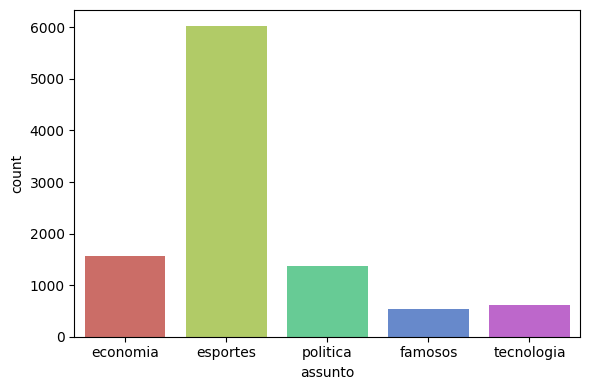

In [7]:
import matplotlib.pyplot as plt # Importar aqui para garantir o uso em outras células de plotagem
import seaborn as sns # Importar aqui para garantir o uso em outras células de plotagem

# Contagem de notícias por assunto
# A coluna 'assunto' representa a categoria da notícia.
plt.rcParams["figure.figsize"] = [6, 4]
plt.rcParams["figure.autolayout"] = True
sns.countplot(x = 'assunto', data=final_df, palette='hls')
plt.show()

## Visualização da Contagem de Notícias por Tema

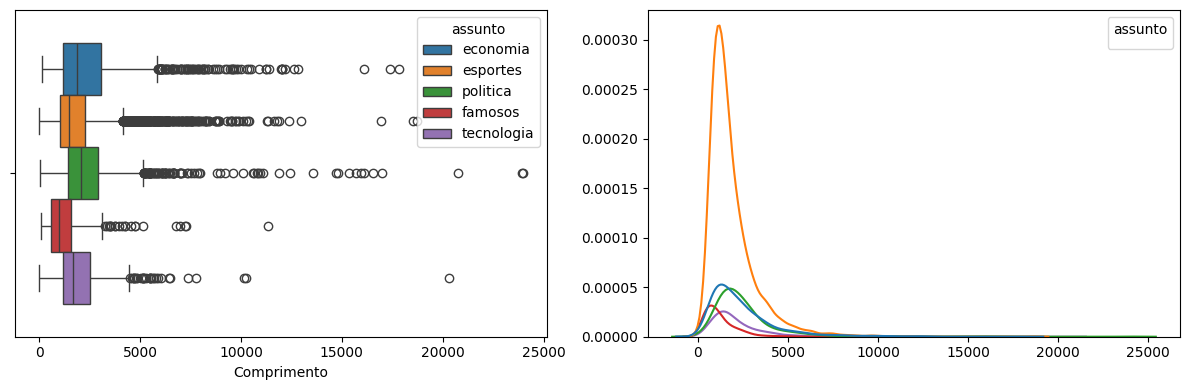

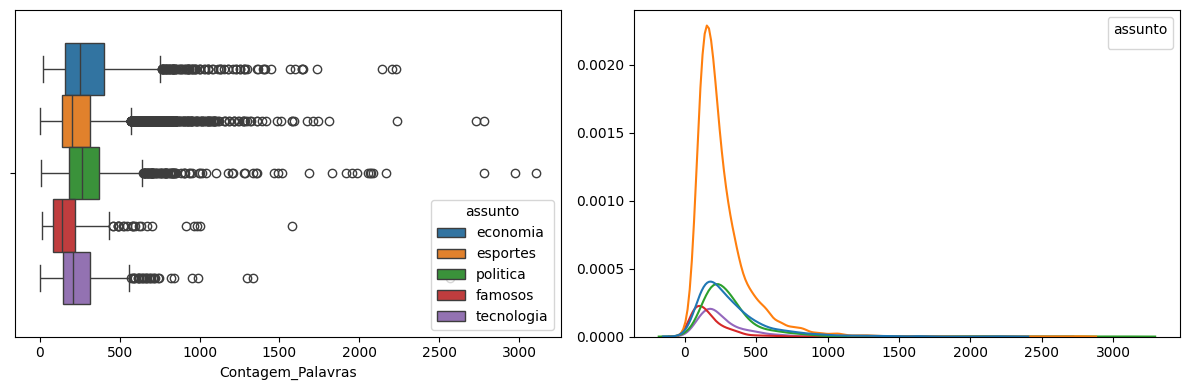

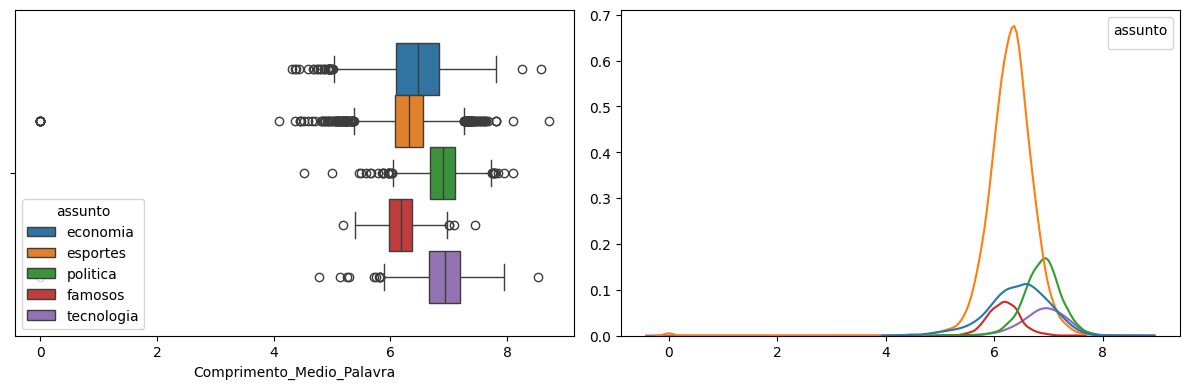

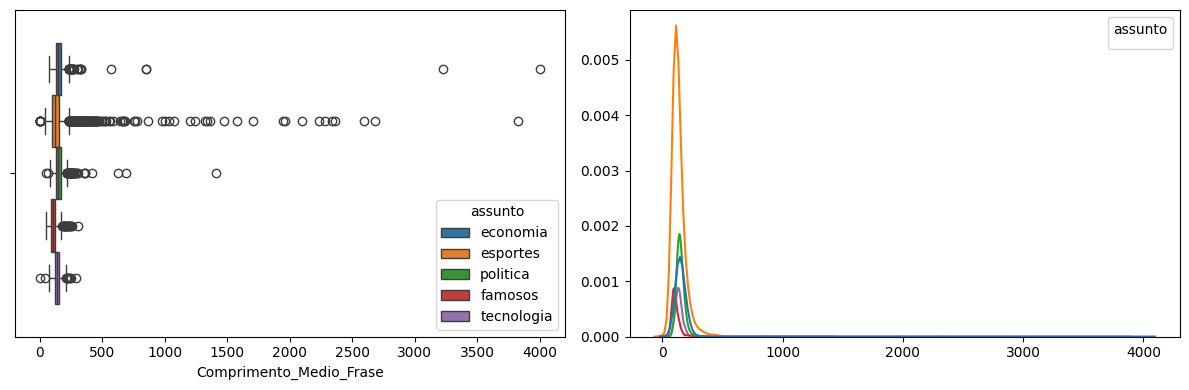

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizar características
def visualizar_caracteristicas(dados: pd.DataFrame, col: str, legenda: str, x_limit_quantile: float = 1.0):

    plt.rcParams["figure.figsize"] = [12, 4]
    plt.rcParams["figure.autolayout"] = True
    f, axes = plt.subplots(1, 2);

    # Boxplot
    sns.boxplot(data=dados, x=col, hue=legenda, ax=axes[0])

    # KDE plot
    sns.kdeplot(data=dados, x=col, hue=legenda, ax=axes[1])

    # Ajustar o limite do eixo x se x_limit_quantile for menor que 1.0
    if x_limit_quantile < 1.0:
        upper_limit = dados[col].quantile(x_limit_quantile)
        axes[1].set_xlim(left=dados[col].min(), right=upper_limit)

    # Adicionar legenda apenas se 'hue' for usado, e para evitar duplicação ou erro com plt.legend()
    # Seaborn já adiciona a legenda automaticamente quando 'hue' é usado no boxplot e kdeplot
    # plt.legend(dados[legenda].unique()) # Removido para evitar legendas duplicadas ou conflitos
    axes[1].legend(title=legenda)

    plt.xlabel('')
    plt.ylabel('')
    plt.show()

# Características para visualizar (selecionando as colunas numéricas relevantes)
caracteristicas = ['Comprimento', 'Contagem_Palavras', 'Comprimento_Medio_Palavra', 'Comprimento_Medio_Frase']
for caracteristica in caracteristicas:
    # Remover a aplicação de x_limit_quantile apenas para 'Comprimento_Medio_Frase'
    visualizar_caracteristicas(final_df, caracteristica, 'assunto')


## Análise Estatística do Comprimento Médio da Frase por Tema

In [9]:
# Exibir estatísticas descritivas para Comprimento_Medio_Frase por assunto
print(final_df.groupby('assunto')['Comprimento_Medio_Frase'].describe())


             count        mean         std        min         25%         50%  \
assunto                                                                         
economia    1558.0  156.873684  131.865792  73.000000  128.907143  146.905702   
esportes    6035.0  140.722165  123.937052   0.000000  100.045224  122.000000   
famosos      540.0  108.233462   32.312552  48.666667   88.014205  101.325000   
politica    1363.0  151.674426   51.302585  48.000000  129.761364  145.857143   
tecnologia   613.0  136.938602   29.692063   0.000000  117.408163  134.260870   

                   75%          max  
assunto                              
economia    169.180481  4005.333333  
esportes    152.333333  3826.000000  
famosos     122.698718   306.833333  
politica    165.404971  1408.166667  
tecnologia  154.000000   292.000000  


Se as estatísticas descritivas acima mostrarem valores muito próximos para a média, mediana e outros quartis entre os diferentes assuntos, então o gráfico está refletindo fielmente a similaridade na distribuição do comprimento médio das frases. Caso haja diferenças sutis que queira explorar, poderíamos tentar ajustar os limites do eixo X do gráfico ou usar outro tipo de visualização que destaque melhor pequenas variações.

In [10]:
# Calcular outliers
outliers_comprimento = final_df[abs(zscore(final_df['Comprimento'])) >= 3 ]
len(outliers_comprimento)

178

## Identificação de Valores Atípicos

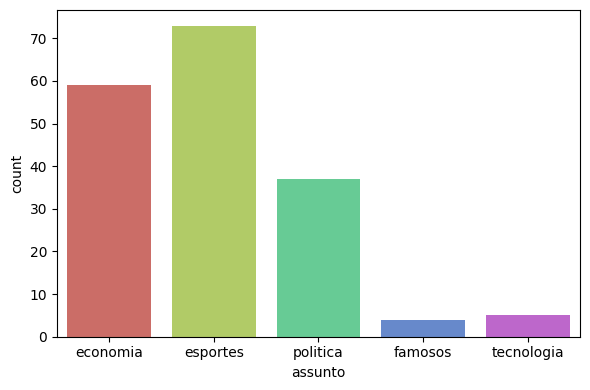

In [11]:
# Exibir a distribuição dos assuntos para os outliers
# A coluna 'assunto' representa a categoria da notícia.
plt.rcParams["figure.figsize"] = [6, 4]
plt.rcParams["figure.autolayout"] = True
sns.countplot(x = 'assunto', data=outliers_comprimento, palette='hls')
plt.show()

## Categorias entre os Textos Atípicos

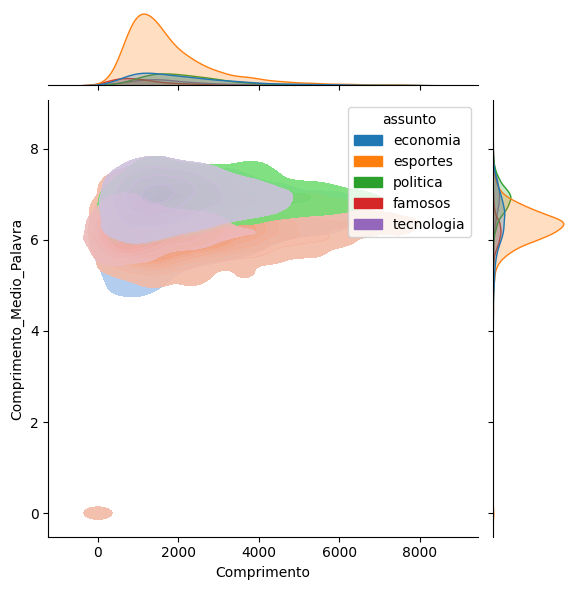

In [12]:
# Verificar a distribuição por assunto
sns.jointplot(x='Comprimento', y='Comprimento_Medio_Palavra', hue='assunto', data=final_df[final_df.Comprimento < final_df.Comprimento.quantile(0.99)], kind='kde', fill=True, joint_kws={'alpha': 0.9});

## Preparação das Nuvens de Palavras

Esta célula instala `wordcloud`, usado na etapa seguinte para visualizar bigramas e trigramas. Em ambientes locais, prefira instalar dependências uma vez no ambiente do projeto em vez de desinstalar pacotes durante a execução do notebook.

In [13]:
# Instala as bibliotecas de nuvem de palavras e visualização.
%pip install wordcloud matplotlib

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Função para criar e exibir nuvem de palavras usando WordCloud
def criar_wordcloud(data: list, title: str):
    # Converter uma lista de strings em uma única string
    text_string = ' '.join(data)

    # Gerar a nuvem de palavras
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          stopwords=cachedStopWords).generate(text_string)

    # Exibir a nuvem de palavras
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Gerar nuvem de palavras para Bigramas
criar_wordcloud(final_df['bigram_text'].dropna().tolist(), 'Nuvem de Palavras para Bigramas')

# Gerar nuvem de palavras para Trigramas
criar_wordcloud(final_df['trigram_text'].dropna().tolist(), 'Nuvem de Palavras para Trigramas')

## Geração e Exibição de Nuvens de Palavras (Bigramas e Trigramas)

In [ ]:
import matplotlib.pyplot as plt # Importar aqui para garantir o uso em outras células de plotagem
import seaborn as sns # Importar aqui para garantir o uso em outras células de plotagem

# Visualizar palavras comuns
def visualizar_palavras_comuns(data: pd.DataFrame, input_col: str, n: int):
    # Obter as N palavras mais comuns usando a função 'obter_top_n_palavras'
    mostCommon = obter_top_n_palavras(data[input_col], n=n)

    # Extrair palavras e suas frequências
    words = []
    freq = []
    for word, count in mostCommon:
        words.append(word)
        freq.append(count)
    return words, freq

# Palavras comuns - Unigramas (palavras únicas)
uni_word, uni_freq = visualizar_palavras_comuns(final_df, 'texto_limpo', 25)

# Plotar Unigramas em um gráfico de barras
plt.rcParams["figure.figsize"] = [8, 6]
plt.rcParams["figure.autolayout"] = True
sns.barplot(x=uni_freq, y=uni_word, palette='viridis')
plt.title('As 25 Palavras Mais Frequentes (Unigramas)') # Título do gráfico
plt.show()

# Palavras comuns - Bigramas (sequências de duas palavras)
bi_word, bi_freq = visualizar_palavras_comuns(final_df, 'bigram_text', 25)
# Substituir o underscore por espaço para melhor leitura no gráfico
bi_word = list(map(lambda x: x.replace('_', ' '), bi_word))

# Plotar Bigramas em um gráfico de barras
plt.rcParams["figure.figsize"] = [8, 6]
plt.rcParams["figure.autolayout"] = True
sns.barplot(x=bi_freq, y=bi_word, palette='magma')
plt.title('As 25 Palavras Mais Frequentes (Bigramas)')
plt.show()

# Palavras comuns - Trigramas (sequências de três palavras)
tri_word, tri_freq = visualizar_palavras_comuns(final_df, 'trigram_text', 25)
# Substituir o underscore por espaço para melhor leitura no gráfico
tri_word = list(map(lambda x: x.replace('_', ' '), tri_word))

# Plotar Trigramas em um gráfico de barras
plt.rcParams["figure.figsize"] = [8, 6]
plt.rcParams["figure.autolayout"] = True
sns.barplot(x=tri_freq, y=tri_word, palette='cividis')
plt.title('As 25 Palavras Mais Frequentes (Trigramas)')
plt.show()

## Frequência de Unigramas, Bigramas e Trigramas

In [ ]:
# Importar displacy do spacy.displacy
from spacy import displacy

# O modelo spaCy já foi carregado globalmente como `nlp_global` na célula de instalação.
# Exemplo de texto para NER (usando a coluna 'conteudo_noticia')
text = final_df['conteudo_noticia'].iloc[0]

# Processar o texto com o modelo spaCy global
text_ner = nlp_global(text)

# Imprimir as entidades nomeadas encontradas neste exemplo de texto.
print("Entidades Nomeadas (NER) encontradas:")
for word in text_ner.ents:
    print(f"{word.text} ({word.label_})")

# Visualizar as entidades nomeadas
print("\nVisualização das Entidades Nomeadas:")
displacy.render(text_ner, style="ent", jupyter=True)

## Reconhecimento de Entidades Nomeadas (NER)

In [ ]:
# POS (Part-of-Speech Tagging - Etiquetagem Morfossintática)
# O modelo spaCy `nlp_global` já foi carregado na célula de instalação.

def identificacao_pos(data: pd.DataFrame, input_col: str, tag: str, sample_size: int, tag_count: int) -> tuple[list, list]:
    # Amostrar dados para processamento mais rápido
    df_sample = data.head(sample_size)

    tags_list = []
    # Processar cada texto na amostra com spaCy, usando a coluna original para melhor reconhecimento de entidades
    for text_item in df_sample['conteudo_noticia'].astype(str).values:
        if pd.isna(text_item) or text_item.strip() == "":
            continue
        doc = nlp_global(text_item)
        # Filtrar tokens que correspondem à tag especificada e não são stopwords
        for token in doc:
            condition = (token.pos_ == tag and token.text.lower() not in sw)

            # Condição adicional para 'ADJ' e 'VERB' para excluir Nomes Próprios ('PROPN')
            if tag in ['ADJ', 'VERB']:
                condition = condition and (token.pos_ != 'PROPN')

            # Excluir também números e palavras de uma única letra para as tags que estamos contando
            condition = condition and len(token.text) > 1 and not token.text.isdigit()

            if condition:
                tags_list.append(token.text.lower())

    # Contar as ocorrências das tags mais comuns
    most_common = Counter(tags_list).most_common(tag_count)

    # Separar palavras e suas frequências para plotagem
    words, frequency = [], []
    for word, count in most_common:
        words.append(word)
        frequency.append(count)
    return words, frequency

# Identificação POS - Adjetivos (ADJ)
adj_word_pos, adj_freq_pos = identificacao_pos(final_df, 'texto_limpo', 'ADJ', 3000, 15)
# Plotar os 15 Adjetivos Mais Frequentes
plt.rcParams["figure.figsize"] = [8, 6]
plt.rcParams["figure.autolayout"] = True
sns.barplot(x=adj_freq_pos, y=adj_word_pos, palette='viridis')
plt.title('Os 15 Adjetivos Mais Frequentes')
plt.show()

# Identificação POS - Substantivos (NOUN)
noun_word_pos, noun_freq_pos = identificacao_pos(final_df, 'texto_limpo', 'NOUN', 3000, 15)
# Plotar os 15 Substantivos Mais Frequentes
plt.rcParams["figure.figsize"] = [8, 6]
plt.rcParams["figure.autolayout"] = True
sns.barplot(x=noun_freq_pos, y=noun_word_pos, palette='magma')
plt.title('Os 15 Substantivos Mais Frequentes')
plt.show()

# Identificação POS - Verbos (VERB)
verb_word_pos, verb_freq_pos = identificacao_pos(final_df, 'texto_limpo', 'VERB', 3000, 15)
# Plotar os 15 Verbos Mais Frequentes
plt.rcParams["figure.figsize"] = [8, 6]
plt.rcParams["figure.autolayout"] = True
sns.barplot(x=verb_freq_pos, y=verb_word_pos, palette='cividis')
plt.title('Os 15 Verbos Mais Frequentes')
plt.show()


## Etiquetagem Morfossintática (POS)

In [ ]:
from sentence_transformers import SentenceTransformer
import pandas as pd # Certificar que pandas está importado para operações com DataFrame
import numpy as np # Certificar que numpy está importado
from sklearn.manifold import TSNE
import plotly.express as px
import matplotlib.pyplot as plt # Importar matplotlib para plotagem estática
import seaborn as sns # Importar seaborn para plotagem estática

# Usar a coluna 'texto_limpo' para as sentenças
sentences = final_df['texto_limpo'].tolist()

# Carregar modelo de embeddings
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = model.encode(sentences, show_progress_bar=True)

# Adicionar embeddings ao DataFrame final para facilitar o manuseio
# Cuidado: a atribuição direta de numpy array grande pode ser lenta, converter para lista ou usar colunas separadas
final_df['embeddings'] = list(embeddings)

# AMOOSTRAGEM PARA TSNE para melhor desempenho e visualização
# Vamos amostrar 2000 documentos para TSNE se houver documentos suficientes
if len(final_df) > 2000:
    df_sampled = final_df.sample(n=2000, random_state=42).copy()
else:
    df_sampled = final_df.copy()

X_sampled = np.array(df_sampled['embeddings'].tolist())

# Gerar TSNE - 2D
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X_sampled)
df_proj_embeddings = pd.DataFrame(X_embedded)
df_proj_embeddings = df_proj_embeddings.rename(columns={0:'x',1:'y'})

# Usar a coluna 'assunto' como rótulo da amostra
df_proj_embeddings['label'] = df_sampled["assunto"].reset_index(drop=True)

# Plotar 2D (Plotly - Comentado para evitar problemas de renderização interativa)
# fig_2d = px.scatter(df_proj_embeddings, x="x", y="y", color="label", title='Visualização 2D de Embeddings (TSNE) - Amostrado', width=700, height=500)
# fig_2d.update_layout(
#     margin=dict(l=20, r=20, t=40, b=20),
#     paper_bgcolor="White",
#     plot_bgcolor="White",
# )
# display(fig_2d)

# Alternativa: Plotagem Estática do TSNE 2D com Matplotlib 
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='x', y='y', hue='label', data=df_proj_embeddings,
    palette=sns.color_palette('hls', n_colors=len(df_proj_embeddings['label'].unique())),
    legend='full', alpha=0.8
)
plt.title('Visualização 2D de Embeddings (TSNE) - Amostrado (Matplotlib)')
plt.xlabel('Componente TSNE 1')
plt.ylabel('Componente TSNE 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Assunto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Gerar TSNE - 3D
tsne_3D = TSNE(n_components=3, random_state=42)
projections_3D = tsne_3D.fit_transform(X_sampled)
df_3D_proj_embeddings = pd.DataFrame(projections_3D)
df_3D_proj_embeddings = df_3D_proj_embeddings.rename(columns={0:'x',1:'y', 2:'z'})

# Usar a coluna 'assunto' como rótulo da amostra
df_3D_proj_embeddings['label'] = df_sampled["assunto"].reset_index(drop=True)

# Plotar 3D (Plotly - Comentado devido a problemas de renderização interativa)

# Alternativa: Plotagem Estática do TSNE 3D com Matplotlib (Adicionado para garantir visualização)
from mpl_toolkits.mplot3d import Axes3D # Importar para plotagem 3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Mapear rótulos para cores
unique_labels = df_3D_proj_embeddings['label'].unique()
colors = sns.color_palette('hls', n_colors=len(unique_labels))
label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

for label, color in label_to_color.items():
    subset = df_3D_proj_embeddings[df_3D_proj_embeddings['label'] == label]
    ax.scatter(subset['x'], subset['y'], subset['z'], color=color, label=label, alpha=0.7)

ax.set_title('Visualização 3D de Embeddings (TSNE) - Amostrado (Matplotlib)')
ax.set_xlabel('Componente TSNE 1')
ax.set_ylabel('Componente TSNE 2')
ax.set_zlabel('Componente TSNE 3')
ax.legend(title='Assunto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Modelagem de Tópicos com BERTopic

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from umap import UMAP

# Vetorizador de modelo com stopwords em português
# Usamos as stopwords já carregadas em 'cachedStopWords'
vectorizer_model = CountVectorizer(stop_words=cachedStopWords)

# O modelo BERTopic requer as sentenças e os embeddings
sentences_for_bertopic = final_df['texto_limpo'].tolist()
embeddings_for_bertopic = np.array(final_df['embeddings'].tolist()) # Usar os embeddings gerados anteriormente

# Inicializar e treinar o modelo BERTopic
bert_model = BERTopic(
    n_gram_range=(1,2), # Considerar unigramas e bigramas para temas mais descritivos
    vectorizer_model=vectorizer_model,
    nr_topics='auto', # Detectar o número de tópicos automaticamente
    min_topic_size=10, # Tamanho mínimo de documentos por tópico
    # A lista de sementes (seed_topic_list) pode ser adaptada para termos em português relacionados a notícias
    # Por exemplo, termos como 'economia', 'política', 'tecnologia', 'saúde', 'esporte', etc.
    seed_topic_list = [
        ['economia', 'mercado', 'inflação', 'finanças'],
        ['política', 'governo', 'eleições', 'congresso'],
        ['tecnologia', 'inovação', 'internet', 'inteligência artificial'],
        ['saúde', 'pandemia', 'doença', 'vacina'],
        ['esporte', 'futebol', 'olimpíadas', 'competição'],
        ['meio ambiente', 'clima', 'desmatamento', 'sustentabilidade']
    ],
    calculate_probabilities=True,
    verbose=True # Para ver o progresso do treinamento
).fit(sentences_for_bertopic, embeddings_for_bertopic)

# Gerar tópicos e probabilidades
bert_topics, bert_probabilities = bert_model.transform(sentences_for_bertopic, embeddings_for_bertopic)

# Número de tópicos para visualizar nos gráficos de barra
# Podemos usar o número real de tópicos encontrados, ou um valor fixo, por exemplo, 10.
bert_topics_count = len(bert_model.get_topics()) # Pega o número de tópicos encontrados pelo modelo

# Visualizar gráficos de barra dos tópicos
print("\nVisualização de Tópicos (Gráfico de Barras):")
display(bert_model.visualize_barchart(top_n_topics=min(10, bert_topics_count)))

# Visualizar documentos e tópicos em um espaço 2D
print("\nVisualização de Documentos (UMAP):")
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine', random_state=42).fit_transform(embeddings_for_bertopic)
display(bert_model.visualize_documents(sentences_for_bertopic, reduced_embeddings=reduced_embeddings, custom_labels=True))

# Visualizar heatmap de similaridade entre tópicos
print("\nVisualização de Heatmap de Tópicos:")
display(bert_model.visualize_heatmap())

# Visualizar hierarquia dos tópicos
print("\nVisualização de Hierarquia de Tópicos:")
display(bert_model.visualize_hierarchy())

# Visualizar ranking de termos por tópico
print("\nVisualização de Ranking de Termos por Tópico:")
display(bert_model.visualize_term_rank())

## Exibição da Lista de Stopwords em Português

In [ ]:
# Exibir a lista de stopwords em português
print("Lista de Stopwords em Português:")
print(cachedStopWords)